<a href="https://colab.research.google.com/github/lbenit/Floristic_map_africa/blob/main/02_UMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install umap-learn

In [ ]:
import numpy as np
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.manifold import trustworthiness
import itertools

In [ ]:
from umap import UMAP

In [ ]:
import plotly.express as px
from sklearn.cluster import AgglomerativeClustering

#Load in data

In [ ]:
!git clone https://github.com/lbenit/Floristic_map_africa.git


Cloning into 'Floristic_map_africa'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 1.35 MiB | 2.70 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
%cd Floristic_map_africa


/content/Floristic_map_africa/Floristic_map_africa


In [ ]:
# Load data
df=pd.read_csv('Data/relative_abundance_data.csv')
df_remove=pd.read_csv('Data/relative_abundance_data_no_singelton.csv')

In [ ]:
df.shape, df_remove.shape

((366, 108), (366, 89))

In [ ]:
# Remove columns that are only zeros
df = df.loc[:, (df != 0).any(axis=0)]
df_remove = df_remove.loc[:, (df_remove != 0).any(axis=0)]

In [ ]:
df_remove.head()

,plot_id,Adansonia,Afzelia,Aganope,Albizia,Aloe,Androstachys,Annona,Antidesma,Artabotrys,...,Syzygium,Tamarindus,Terminalia,Thespesia,Uapaca,Vachellia,Vernonia,Vitex,Zanha,Ziziphus
0,MAR_1,0.0,0.0,0.0,0.152066,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.013941,0.01465,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,MAR_10,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,MAR_100,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,MAR_102,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,MAR_105,0.0,0.0,0.0,0.000000,0.0,0.0,0.420727,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.head()

,plot_id,Acacia indet,Adansonia digitata,Adenium multiflorum,Afrocanthium burttii,Afzelia quanzensis,Aganope stuhlmannii,Albizia adianthifolia,Albizia amara,Albizia anthelmintica,...,Zanthoxylum chalybeum,Zanthoxylum davyi,Zanthoxylum deremense,Zanthoxylum holtzianum,Zanthoxylum indet,Ziziphus abyssinica,Ziziphus indet,Ziziphus mauritiana,Ziziphus mucronata,Ziziphus pubescens
0,ABG_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ABG_10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ABG_11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ABG_12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ABG_13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Set plot_id as index
df=df.set_index('plot_id')
df_remove=df_remove.set_index('plot_id')

# Convert using hellinger

In [ ]:
# Convert to hellinger
def hellinger(df):
    df = df.div(df.sum(axis=1), axis=0)   # row-wise relative abundance
    df = np.sqrt(df)                      # square root transform
    return df

df_remove = hellinger(df_remove)
df = hellinger(df)

In [ ]:
df_remove.shape

(7783, 266)

In [ ]:
df.head()

,Acacia,Adansonia,Adenium,Afrocanthium,Afzelia,Aganope,Albizia,Alchornea,Allophylus,Aloe,...,Wrightia,Xanthocersis,Xeroderris,Ximenia,Xylia,Xylopia,Xylotheca,Zanha,Zanthoxylum,Ziziphus
plot_id,,,,,,,,,,,,,,,,,,,,,
ABG_1,0.0,0.0,0.0,0.0,0.0,0.0,0.009627,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002617,0.0,0.0
ABG_10,0.0,0.0,0.0,0.0,0.0,0.0,0.017013,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
ABG_11,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
ABG_12,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
ABG_13,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


# Test for best parameters

In [ ]:
# ------------------------------------------------------------
# Continuity function
# ------------------------------------------------------------
def continuity(X, X_embedded, n_neighbors=10):
    D_high = pairwise_distances(X)
    D_low  = pairwise_distances(X_embedded)

    R_high = np.argsort(np.argsort(D_high, axis=1), axis=1)
    R_low  = np.argsort(np.argsort(D_low, axis=1), axis=1)

    n = X.shape[0]
    k = n_neighbors

    C = 0
    for i in range(n):
        low_nn = np.argsort(D_low[i])[1:k+1]
        high_nn = np.argsort(D_high[i])[1:k+1]

        missing = [j for j in low_nn if j not in high_nn]

        for j in missing:
            C += (R_high[i, j] - k)

    denom = n * k * (2*n - 3*k - 1)
    return 1 - (2 * C) / denom


In [ ]:

# ------------------------------------------------------------
# Parameter grid
# ------------------------------------------------------------
n_neighbors_list = [100,200, 300]
min_dist_list = [0.05,0.25,0.5]

grid = list(itertools.product(n_neighbors_list, min_dist_list))

results = []

# ------------------------------------------------------------
# Run UMAP for each parameter combination
# ------------------------------------------------------------
for nn, md in grid:
    print(f"Running UMAP with n_neighbors={nn}, min_dist={md}")

    umap_model = UMAP(
        n_neighbors=nn,
        min_dist=md,
        metric="braycurtis",
        n_components=3,
        n_jobs=-1)
        #random_state=17

    umap_embed = umap_model.fit_transform(df)

    # --------------------------------------------------------
    # Clustering for silhouette
    # --------------------------------------------------------
    d = pdist(umap_embed, metric="euclidean")
    d_matrix = squareform(d)

    hc = linkage(d, method="ward")
    clusters = fcluster(hc, t=3, criterion="maxclust")


    # for silhouette, you need the square matrix:
    sil = silhouette_score(d_matrix, clusters, metric="precomputed")

    # --------------------------------------------------------
    # Dimensionality reduction metrics
    # --------------------------------------------------------
    tw = trustworthiness(df, umap_embed, n_neighbors=nn)
    cont = continuity(df, umap_embed, n_neighbors=nn)

    results.append({
        "n_neighbors": nn,
        "min_dist": md,
        "trustworthiness": tw,
        "continuity": cont,
        "silhouette": sil
    })

scores_df = pd.DataFrame(results)
scores_df




Running UMAP with n_neighbors=100, min_dist=0.05
Running UMAP with n_neighbors=100, min_dist=0.25
Running UMAP with n_neighbors=100, min_dist=0.5
Running UMAP with n_neighbors=200, min_dist=0.05
Running UMAP with n_neighbors=200, min_dist=0.25
Running UMAP with n_neighbors=200, min_dist=0.5
Running UMAP with n_neighbors=300, min_dist=0.05
Running UMAP with n_neighbors=300, min_dist=0.25
Running UMAP with n_neighbors=300, min_dist=0.5


,n_neighbors,min_dist,trustworthiness,continuity,silhouette
0,100,0.05,0.919284,0.921230,0.837198
1,100,0.25,0.910207,0.911889,0.635212
2,100,0.50,0.900082,0.901950,0.410658
3,200,0.05,0.891881,0.894199,0.835346
4,200,0.25,0.890580,0.894454,0.711123
5,200,0.50,0.882277,0.886151,0.657294
6,300,0.05,0.876001,0.879382,0.826266
7,300,0.25,0.869158,0.871386,0.798805
8,300,0.50,0.866550,0.871551,0.435484


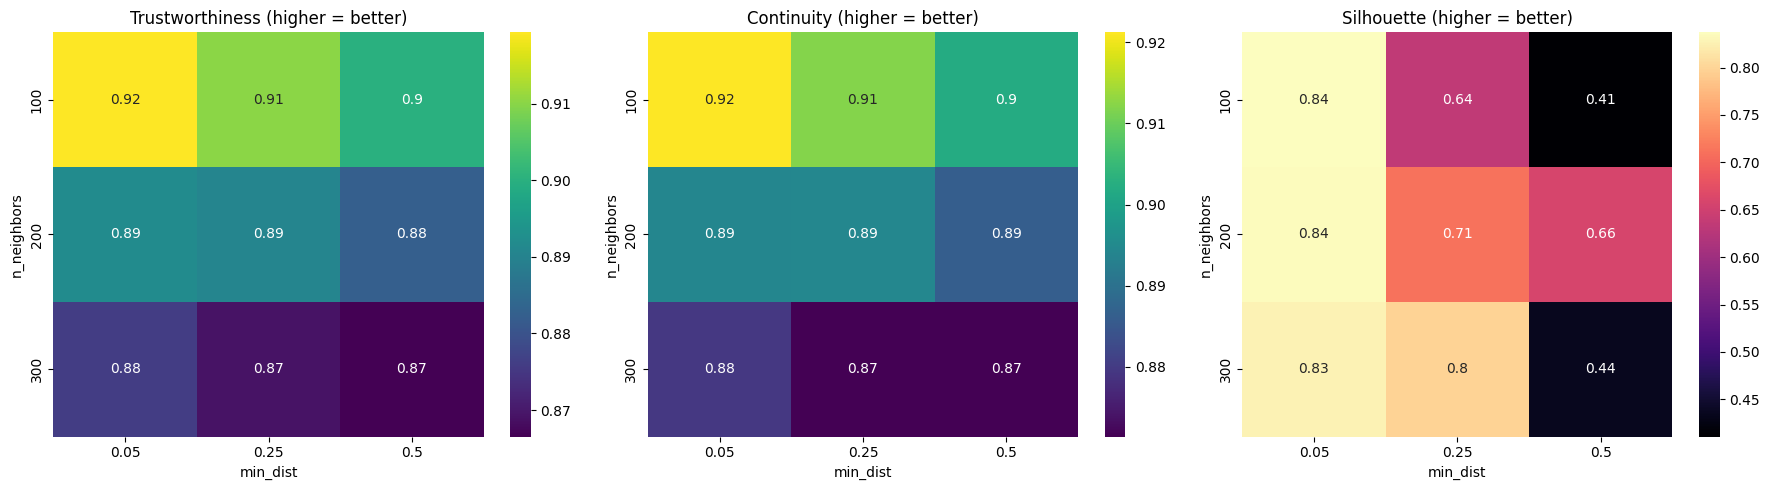

In [ ]:
# Pivot tables
tw_pivot = scores_df.pivot(
    index="n_neighbors",
    columns="min_dist",
    values="trustworthiness"
)

cont_pivot = scores_df.pivot(
    index="n_neighbors",
    columns="min_dist",
    values="continuity"
)

sil_pivot = scores_df.pivot(
    index="n_neighbors",
    columns="min_dist",
    values="silhouette"
)


plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.heatmap(tw_pivot, annot=True, cmap="viridis")
plt.title("Trustworthiness (higher = better)")

plt.subplot(1, 3, 2)
sns.heatmap(cont_pivot, annot=True, cmap="viridis")
plt.title("Continuity (higher = better)")

plt.subplot(1, 3, 3)
sns.heatmap(sil_pivot, annot=True, cmap="magma")
plt.title("Silhouette (higher = better)")

plt.tight_layout()
plt.show()


In [ ]:
# Best scores
# Trustworthiness 50, 0.075 or 0.125
# Continuity 50, 0.075 or 0.125
# Silhouette 125 0.05 or 0.1

# Calculate UMAP with the best min_dist and *n_neighbors*

In [ ]:
from umap.parametric_umap import ParametricUMAP

In [ ]:
# Run UMAP
# Run best UMAP model based on selected parameters
umap_model = ParametricUMAP(
    n_neighbors=100,
    min_dist=0.05,
    n_components=3,
    metric="braycurtis",
    verbose=True,
    random_state=17
)

embedding = umap_model.fit_transform(df_remove)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ParametricUMAP()
Tue Aug 11 10:30:26 2026 Construct fuzzy simplicial set
Tue Aug 11 10:30:26 2026 Finding Nearest Neighbors
Tue Aug 11 10:30:30 2026 Finished Nearest Neighbor Search
Tue Aug 11 10:30:37 2026 Construct embedding
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'umap_model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.3156
Epoch 2/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.2986
Epoch 3/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.2976
Epoch 4/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.2981
Epoch 5/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.2976
Epoch 6/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.2982
Epoch 7/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.2975
Epoch 8/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.2979
Epoch 9/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2980
Epoch 10/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.2979
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Tue Aug 11 10:32:02 2026 Finished embedding


In [ ]:
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2', 'UMAP3'])
embedding_df.index = df_remove.index
embedding_df.head()

,UMAP1,UMAP2,UMAP3
plot_id,,,
MAR_1,-0.968939,-0.574914,-0.456427
MAR_10,1.234848,3.280520,0.876849
MAR_100,-0.912209,0.077260,-0.221219
MAR_102,1.296430,3.561313,1.141701
MAR_105,-0.657446,0.029933,0.825259


# Test points for singularity
This checks that there aren't too many points that make the distribution of points in UMAP space unstable. Based off of the following paper:
Liu, Z., Ma, R., & Zhong, Y. (2025). Assessing and improving reliability of neighbor embedding methods: A map-continuity perspective. Nature Communications, 16(1), 5037. https://doi.org/10.1038/s41467-025-60434-9

In [ ]:
def knn_indices(X, k):
    """
    Return indices of k nearest neighbours for each point (excluding self).
    X: (n_samples, n_features)
    """
    dist = pairwise_distances(X)
    # argsort along rows, drop self (index 0 after sorting)
    idx = np.argsort(dist, axis=1)[:, 1:k+1]
    return idx


In [ ]:
# Create a function to examine the perturbation and singularity of each point
def perturbation_and_singularity_scores(X_high, X_low, k=15):
    """
    Compute per-point perturbation and singularity scores.

    X_high: high-dimensional data, shape (n_samples, D)
    X_low:  low-dimensional embedding, shape (n_samples, d)
    k:      neighborhood size

    Returns
    -------
    perturbation: np.ndarray of shape (n_samples,)
    singularity:  np.ndarray of shape (n_samples,)
    """

    n = X_high.shape[0]

    # k-NN in high- and low-dimensional spaces
    knn_high = knn_indices(X_high, k)  # shape (n, k)
    knn_low  = knn_indices(X_low,  k)  # shape (n, k)

    # For convenience, build "who considers i as neighbor" sets
    # high_inv[i] = set of points j for which i is in knn_high[j]
    high_inv = [set() for _ in range(n)]
    low_inv  = [set() for _ in range(n)]

    for j in range(n):
        for nb in knn_high[j]:
            high_inv[nb].add(j)
        for nb in knn_low[j]:
            low_inv[nb].add(j)

    perturbation = np.zeros(n, dtype=float)
    singularity  = np.zeros(n, dtype=float)

    for i in range(n):
        # Points that see i as neighbor in low-dim but not in high-dim
        overconf = low_inv[i] - high_inv[i]
        # Points that see i as neighbor in high-dim but not in low-dim
        fracture = high_inv[i] - low_inv[i]

        # Normalise by k to keep scores in [0, 1] (roughly)
        perturbation[i] = len(overconf) / k
        singularity[i]  = len(fracture) / k

    return perturbation, singularity


In [ ]:
# Run code and save scores

perturbation, singularity = perturbation_and_singularity_scores(df_remove, embedding_df, k=15)

# Example: add to a dataframe
embedding_df["perturbation"] = perturbation
embedding_df["singularity"]  = singularity


In [ ]:
embedding_df.shape

(366, 5)

In [ ]:
# Remove high singularity points as they have very different floristics
embedding_df = embedding_df[embedding_df["singularity"] < 10]

# Clustering

In [ ]:
# Keep only UMAP scores
embedding=embedding_df[['UMAP1','UMAP2','UMAP3']].values

In [ ]:
# Calculate for mulitple k
# Make a copy so you don't overwrite the original
results=[]

for k in range(2, 10):  # k = 2 to 10
    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        metric="euclidean"
    )

    labels = hc.fit_predict(embedding)

    # Add labels as a new column in the dataframe
    embedding_df.loc[:, f"cluster{k}"] = labels

    # Compute silhouette score
    score = silhouette_score(embedding, labels)
    results.append({"k": k, "silhouette": score})

# Silhouette summary table
sil_df = pd.DataFrame(results)
print(sil_df)

# df now contains cluster_k2 ... cluster_k10
embedding_df.head()


   k  silhouette
0  2    0.550476
1  3    0.614861
2  4    0.682576
3  5    0.609643
4  6    0.550789
5  7    0.546402
6  8    0.519666
7  9    0.492778


,UMAP1,UMAP2,UMAP3,perturbation,singularity,cluster2,cluster3,cluster4,cluster5,cluster6,cluster7,cluster8,cluster9
plot_id,,,,,,,,,,,,,
MAR_1,-0.968939,-0.574914,-0.456427,0.266667,0.200000,0,0,0,4,4,4,4,4
MAR_10,1.234848,3.280520,0.876849,1.400000,0.066667,1,1,1,0,2,0,1,0
MAR_100,-0.912209,0.077260,-0.221219,0.200000,0.666667,0,0,0,4,4,4,4,4
MAR_102,1.296430,3.561313,1.141701,0.866667,0.600000,1,1,1,0,2,0,1,0
MAR_105,-0.657446,0.029933,0.825259,0.266667,0.200000,0,0,0,4,4,4,4,4


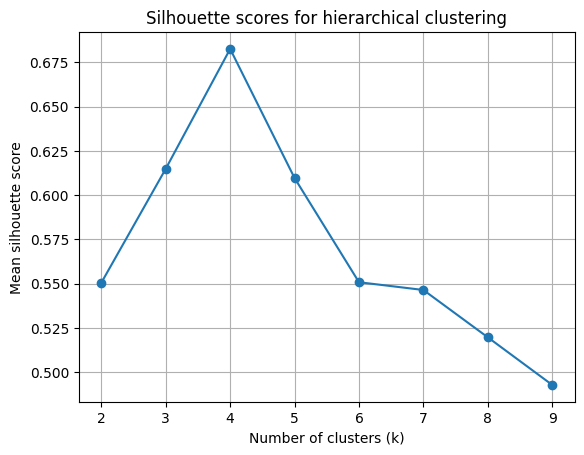

In [ ]:
# PLot silhouette scores

plt.plot(sil_df["k"], sil_df["silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Mean silhouette score")
plt.title("Silhouette scores for hierarchical clustering")
plt.grid(True)
plt.show()


In [ ]:
# Print scores for silhouette and calinki scores for each number of clusters
from sklearn.metrics import silhouette_score, calinski_harabasz_score

results = []

for k in range(2, 10):
    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        metric="euclidean"
    )

    labels = hc.fit_predict(embedding)

     # Add labels as a new column in the dataframe
    embedding_df.loc[:, f"cluster{k}"] = labels

    sil = silhouette_score(embedding, labels)
    ch  = calinski_harabasz_score(embedding, labels)


    results.append({
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch
    })

results_df = pd.DataFrame(results)
print(results_df)


   k  silhouette  calinski_harabasz
0  2    0.550476         624.572083
1  3    0.614861         893.701233
2  4    0.682576        1331.563599
3  5    0.609643        1376.870850
4  6    0.550789        1602.767700
5  7    0.546402        1613.903076
6  8    0.519666        1658.642700
7  9    0.492778        1720.641968


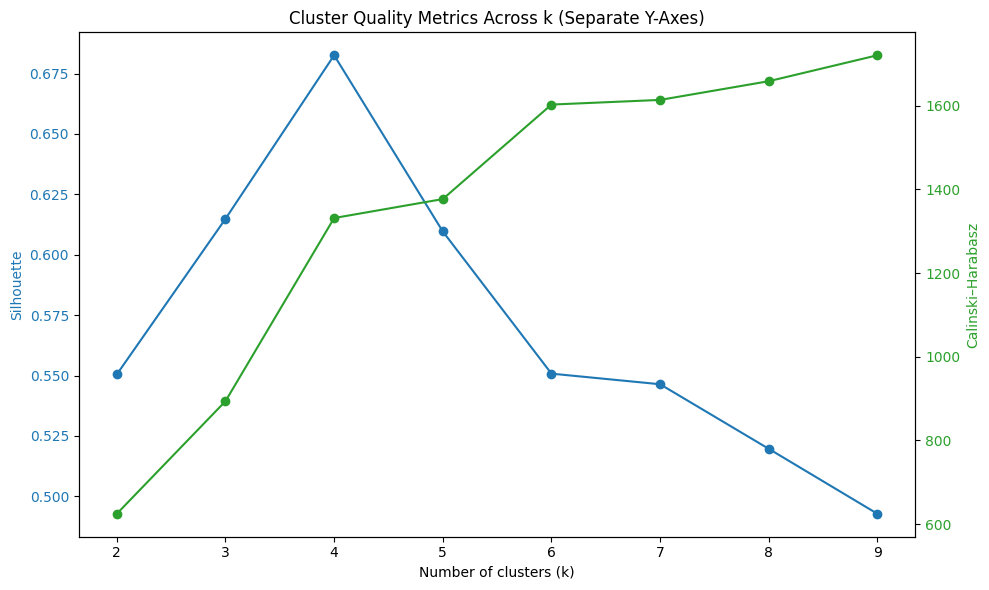

In [ ]:
# Create supplemental figure 1
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Silhouette (left axis) ---
ax1.plot(results_df["k"], results_df["silhouette"],
         marker="o", color="tab:blue", label="Silhouette")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Silhouette", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# --- Calinski–Harabasz (right axis #1) ---
ax2 = ax1.twinx()
ax2.plot(results_df["k"], results_df["calinski_harabasz"],
         marker="o", color="tab:green", label="Calinski–Harabasz")
ax2.set_ylabel("Calinski–Harabasz", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")



# Title and layout
plt.title("Cluster Quality Metrics Across k (Separate Y-Axes)")
fig.tight_layout()
plt.show()


In [ ]:
# View seven clusters in 3D UMAP space

fig = px.scatter_3d(
    embedding_df,
    x="UMAP1",
    y="UMAP2",
    z="UMAP3",
    color="cluster7",
    opacity=0.7
)

fig.show()


In [ ]:
embedding_df['cluster7'].unique()

array([4, 0, 2, 1, 5, 6, 3])

# Create columns that show the lineage of each plot
This is used to create the flow diagram in figure 1D. The code for the figure is made in a separate script.


In [ ]:
embedding_df.head()

,UMAP1,UMAP2,UMAP3,perturbation,singularity,cluster2,cluster3,cluster4,cluster5,cluster6,cluster7,cluster8,cluster9
plot_id,,,,,,,,,,,,,
MAR_1,-0.968939,-0.574914,-0.456427,0.266667,0.200000,0,0,0,4,4,4,4,4
MAR_10,1.234848,3.280520,0.876849,1.400000,0.066667,1,1,1,0,2,0,1,0
MAR_100,-0.912209,0.077260,-0.221219,0.200000,0.666667,0,0,0,4,4,4,4,4
MAR_102,1.296430,3.561313,1.141701,0.866667,0.600000,1,1,1,0,2,0,1,0
MAR_105,-0.657446,0.029933,0.825259,0.266667,0.200000,0,0,0,4,4,4,4,4


In [ ]:

def align_clusters(df, ks):
    """
    df : DataFrame with columns 'cluster{k}' for k in ks
    ks : sorted list of k values, e.g. [3,4,5,6,7,8,9,10]
    """
    ks = sorted(ks)

    # 1) initialise: first lineage is just cluster labels as strings
    first_k = ks[0]
    df[f"lineage{first_k}"] = df[f"cluster{first_k}"].astype(str)

    # 2) iterate over subsequent k values
    for i in range(1, len(ks)):
        k_prev = ks[i-1]
        k_curr = ks[i]

        prev_col = f"lineage{k_prev}"
        curr_col = f"cluster{k_curr}"
        new_col  = f"lineage{k_curr}"

        # safety check: required columns exist
        if prev_col not in df.columns:
            raise KeyError(f"Missing column: {prev_col}")
        if curr_col not in df.columns:
            raise KeyError(f"Missing column: {curr_col}")

        # compute overlap between parent lineages and current clusters
        overlap = (
            df.groupby([prev_col, curr_col])
              .size()
              .reset_index(name="count")
        )

        prev_lineages = overlap[prev_col].unique()
        curr_clusters = overlap[curr_col].unique()

        # track how many children each parent already has
        children_per_parent = {p: 0 for p in prev_lineages}
        mapping = {}

        for child in curr_clusters:
            sub = overlap[overlap[curr_col] == child]

            # pick parent with max overlap
            best_parent = sub.sort_values("count", ascending=False).iloc[0][prev_col]

            children_per_parent[best_parent] += 1
            n_child = children_per_parent[best_parent]

            if n_child == 1:
                # first child keeps parent's name
                mapping[child] = best_parent
            else:
                # subsequent children get suffixes
                mapping[child] = f"{best_parent}.{n_child-1}"

        # apply mapping to create new lineage column
        df[new_col] = df[curr_col].map(mapping).astype(str)

    return df


In [ ]:
ks = [2,3,4, 5,6, 7, 8]

align_clusters(embedding_df, ks)

,UMAP1,UMAP2,UMAP3,perturbation,singularity,cluster2,cluster3,cluster4,cluster5,cluster6,cluster7,cluster8,cluster9,lineage2,lineage3,lineage4,lineage5,lineage6,lineage7,lineage8
plot_id,,,,,,,,,,,,,,,,,,,,
MAR_1,-0.968939,-0.574914,-0.456427,0.266667,0.200000,0,0,0,4,4,4,4,4,0,0,0,0.1,0.1.1,0.1.1.1,0.1.1.1
MAR_10,1.234848,3.280520,0.876849,1.400000,0.066667,1,1,1,0,2,0,1,0,1,1,1,1,1,1,1
MAR_100,-0.912209,0.077260,-0.221219,0.200000,0.666667,0,0,0,4,4,4,4,4,0,0,0,0.1,0.1.1,0.1.1.1,0.1.1.1
MAR_102,1.296430,3.561313,1.141701,0.866667,0.600000,1,1,1,0,2,0,1,0,1,1,1,1,1,1,1
MAR_105,-0.657446,0.029933,0.825259,0.266667,0.200000,0,0,0,4,4,4,4,4,0,0,0,0.1,0.1.1,0.1.1.1,0.1.1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MAR_92,0.193367,2.849566,1.332523,1.533333,0.333333,1,1,1,0,2,0,1,0,1,1,1,1,1,1,1
MAR_93,0.052259,3.190367,1.622767,0.733333,0.466667,1,1,1,0,2,0,1,0,1,1,1,1,1,1,1
MAR_94,0.536457,3.053711,1.182900,0.800000,1.000000,1,1,1,0,2,0,1,0,1,1,1,1,1,1,1


In [ ]:
embedding_df.head()

,UMAP1,UMAP2,UMAP3,perturbation,singularity,cluster2,cluster3,cluster4,cluster5,cluster6,cluster7,cluster8,cluster9,lineage2,lineage3,lineage4,lineage5,lineage6,lineage7,lineage8
plot_id,,,,,,,,,,,,,,,,,,,,
MAR_1,-0.968939,-0.574914,-0.456427,0.266667,0.200000,0,0,0,4,4,4,4,4,0,0,0,0.1,0.1.1,0.1.1.1,0.1.1.1
MAR_10,1.234848,3.280520,0.876849,1.400000,0.066667,1,1,1,0,2,0,1,0,1,1,1,1,1,1,1
MAR_100,-0.912209,0.077260,-0.221219,0.200000,0.666667,0,0,0,4,4,4,4,4,0,0,0,0.1,0.1.1,0.1.1.1,0.1.1.1
MAR_102,1.296430,3.561313,1.141701,0.866667,0.600000,1,1,1,0,2,0,1,0,1,1,1,1,1,1,1
MAR_105,-0.657446,0.029933,0.825259,0.266667,0.200000,0,0,0,4,4,4,4,4,0,0,0,0.1,0.1.1,0.1.1.1,0.1.1.1


In [ ]:


# Assuming embedding_df has columns cluster3, cluster4, ..., cluster10

transitions = []

for k in range(3, 7):  # transitions from k → k+1
    c1 = f"lineage{k}"
    c2 = f"lineage{k+1}"

    # Count transitions
    counts = (
        embedding_df.groupby([c1, c2])
        .size()
        .reset_index(name="count")
    )

    counts["from"] = counts[c1].astype(str) + f"_k{k}"
    counts["to"] = counts[c2].astype(str) + f"_k{k+1}"
    transitions.append(counts[["from", "to", "count"]])

transition_df = pd.concat(transitions, ignore_index=True)
transition_df


,from,to,count
0,0_k3,0_k4,125
1,0_k3,0.1_k4,22
2,0.1_k3,0.1_k4,60
3,1_k3,1_k4,159
4,0_k4,0_k5,73
5,0_k4,0.1_k5,52
6,0.1_k4,0.1_k5,60
7,0.1_k4,0.1.1_k5,22
8,1_k4,1_k5,159
9,0_k5,0_k6,73


In [ ]:
def build_transitions(df, k_min=3, k_max=7):
    transitions = []

    for k in range(k_min, k_max):
        col_from = f"cluster{k}"
        col_to   = f"cluster{k+1}"

        tmp = (
            df.groupby([col_from, col_to])
              .size()
              .reset_index(name="count")
              .rename(columns={col_from: "from_cluster",
                               col_to: "to_cluster"})
        )
        tmp["from_k"] = k
        tmp["to_k"] = k+1
        transitions.append(tmp)

    return pd.concat(transitions, ignore_index=True)

transition_df = build_transitions(embedding_df)


In [ ]:
def assign_lineages(transition_df):
    lineage_id = {}
    next_lineage = 0

    # Initialize lineages at k=2
    roots = transition_df[transition_df["from_k"] == 3]["from_cluster"].unique()
    for c in roots:
        lineage_id[(3, c)] = next_lineage
        next_lineage += 1

    # Propagate lineages forward
    for k in range(3, transition_df["to_k"].max()):
        subset = transition_df[transition_df["from_k"] == k]

        for (from_cluster, group) in subset.groupby("from_cluster"):
            parent_lineage = lineage_id[(k, from_cluster)]

            # Sort children by flow size (largest first)
            children = group.sort_values("count", ascending=False)

            first = True
            for _, row in children.iterrows():
                child = row["to_cluster"]
                if first:
                    # Main branch keeps the lineage
                    lineage_id[(k+1, child)] = parent_lineage
                    first = False
                else:
                    # Splits get new lineage IDs
                    lineage_id[(k+1, child)] = next_lineage
                    next_lineage += 1

    return lineage_id

lineage_id = assign_lineages(transition_df)


In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt # Import pyplot for colormaps

# Build node names
transition_df["from_node"] = transition_df.apply(
    lambda r: f"k{r['from_k']}_c{r['from_cluster']}", axis=1
)
transition_df["to_node"] = transition_df.apply(
    lambda r: f"k{r['to_k']}_c{r['to_cluster']}", axis=1
)

nodes = pd.unique(transition_df[["from_node", "to_node"]].values.ravel())
node_index = {n: i for i, n in enumerate(nodes)}

# Extract lineage for each node
node_lineage = {
    n: lineage_id[(int(n.split("_")[0][1:]), int(n.split("_")[1][1:]))]
    for n in nodes
}

# Assign colors by lineage
unique_lineages = sorted(set(node_lineage.values()))
# Updated to use the non-deprecated method for getting colormaps with keyword argument for lut
cmap = plt.colormaps.get_cmap("tab20", lut=len(unique_lineages))
lineage_colors = {L: mcolors.to_hex(cmap(i)) for i, L in enumerate(unique_lineages)}

node_colors = [lineage_colors[node_lineage[n]] for n in nodes]


TypeError: ColormapRegistry.get_cmap() takes 2 positional arguments but 3 were given

In [ ]:
sources = transition_df["from_node"].map(node_index).tolist()
targets = transition_df["to_node"].map(node_index).tolist()
values  = transition_df["count"].tolist()

link_colors = [
    node_colors[src] for src in sources
]


In [ ]:
# Extract k-level for each node
node_k = {n: int(n.split("_")[0][1:]) for n in nodes}

# Group nodes by k-level
levels = {}
for n in nodes:
    k = node_k[n]
    levels.setdefault(k, []).append(n)

# Sort nodes within each k by lineage ID
for k in levels:
    levels[k] = sorted(levels[k], key=lambda n: node_lineage[n])

# Assign y positions (0–1) based on sorted order
node_y = [0] * len(nodes)
for k, group in levels.items():
    for i, n in enumerate(group):
        node_y[node_index[n]] = i / (len(group) + 1)


In [ ]:
embedding_df.head()

,UMAP1,UMAP2,UMAP3,perturbation,singularity,cluster2,cluster3,cluster4,cluster5,cluster6,cluster7,cluster8,cluster9,lineage2,lineage3,lineage4,lineage5,lineage6,lineage7,lineage8
plot_id,,,,,,,,,,,,,,,,,,,,
MAR_1,-0.968939,-0.574914,-0.456427,0.266667,0.200000,0,0,0,4,4,4,4,4,0,0,0,0.1,0.1.1,0.1.1.1,0.1.1.1
MAR_10,1.234848,3.280520,0.876849,1.400000,0.066667,1,1,1,0,2,0,1,0,1,1,1,1,1,1,1
MAR_100,-0.912209,0.077260,-0.221219,0.200000,0.666667,0,0,0,4,4,4,4,4,0,0,0,0.1,0.1.1,0.1.1.1,0.1.1.1
MAR_102,1.296430,3.561313,1.141701,0.866667,0.600000,1,1,1,0,2,0,1,0,1,1,1,1,1,1,1
MAR_105,-0.657446,0.029933,0.825259,0.266667,0.200000,0,0,0,4,4,4,4,4,0,0,0,0.1,0.1.1,0.1.1.1,0.1.1.1


In [ ]:
# Make plot id a column
embedding_df.reset_index(inplace=True)

In [ ]:
# Save df
embedding_df.to_csv("Data/all_data_umap_clusters_parametric.csv", index=False)

In [ ]:
# get dimensions of the data
embedding_df.shape

(7769, 21)

# Get genus scores

In [ ]:
# Load embedding
embedding_df = pd.read_csv("Data/all_data_umap_clusters_parametric.csv")

In [ ]:
emb_train=embedding_df[['UMAP1','UMAP2','UMAP3']]

In [ ]:
# Weighted average species/genus scores (exact wascores equivalent)
numerator = df_remove.T.values @ emb_train.values      # genera × 3
denominator = df_remove.sum(axis=0).values[:, None]      # genera × 1

genus_scores = numerator / denominator               # genera × 3

# Convert back to DataFrame
genus_scores = pd.DataFrame(
    genus_scores,
    index=df_remove.columns,
    columns=['UMAP1','UMAP2','UMAP3']
)


genus_scores.head()


,UMAP1,UMAP2,UMAP3
Adansonia,-0.130504,1.108722,0.834196
Afzelia,-1.574868,-2.112786,-0.679817
Aganope,-1.420020,-1.659679,0.121508
Albizia,-1.190617,-1.288657,-0.777607
Aloe,-0.458129,1.664607,0.409387


In [ ]:
# Check shape
genus_scores.shape

(88, 3)

In [ ]:
# Make genera into a column
genus_scores['genus'] = genus_scores.index

In [ ]:
genus_scores.head()

,UMAP1,UMAP2,UMAP3,genus
Adansonia,-0.130504,1.108722,0.834196,Adansonia
Afzelia,-1.574868,-2.112786,-0.679817,Afzelia
Aganope,-1.420020,-1.659679,0.121508,Aganope
Albizia,-1.190617,-1.288657,-0.777607,Albizia
Aloe,-0.458129,1.664607,0.409387,Aloe


In [ ]:
# Save
genus_scores.to_csv("Data/UMAP_genus_scores_all_points.csv")